
### Fast Adaptation Using Meta-Learning

The challenge: Most conventional Deep Learning models use datasets that are quite large, often containing thousands of examples for each of the tasks being performed. Training a neural network that can recognize a hundred different objects and you would like it to learn a 101st object - would usually require you to acquire thousands of examples of this new object, and retrain for hours, which is a very expensive computation and many gigabytes of data are wasted in the process. Meanwhile humans - in most situations - could probably recognize the object from 1 or 2 images. Most models cannot generalize to few examples, often they completely overfit the new examples.


The solution: The core of the project is the use of a framework that we call Meta-Learning, in particular, an architecture called Prototypical Networks (ProtoNets) that is entirely based on metrics, with no complicated gradient operations being required at all. The idea is that instead of making the model learn classes by themselves, we will teach it how to learn them.


How it works: Rather than performing complex and computationally intensive gradient updates to learn a new class, we will instead teach it to learn a set of good "distance" metric. The model will learn to classify any new, unseen category given only a very small support set - say 1 to 5 images per class - into a high-dimensional vector - its Prototype - that will lie within the model’s latent space. Given any query image, the model would classify it simply based on its geometric distance to the prototypes in its memory space.
Results: As is clear below, due to its architecture, the model never overfits small datasets, yielding solid generalization performances required for top journal publication. To demonstrate its robustness, the model was trained on a set of training classes and tested on classes completely disjoint from the set it was initially trained on. As it is illustrated on the dashboard below, after being given just one image per new class (1-Shot), the network would be able to classifying it efficiently. Additionally, since learning new classes involves calculation of the distance between the average images in prototype space, we can expect for models adaptation speed near to instantaneously.

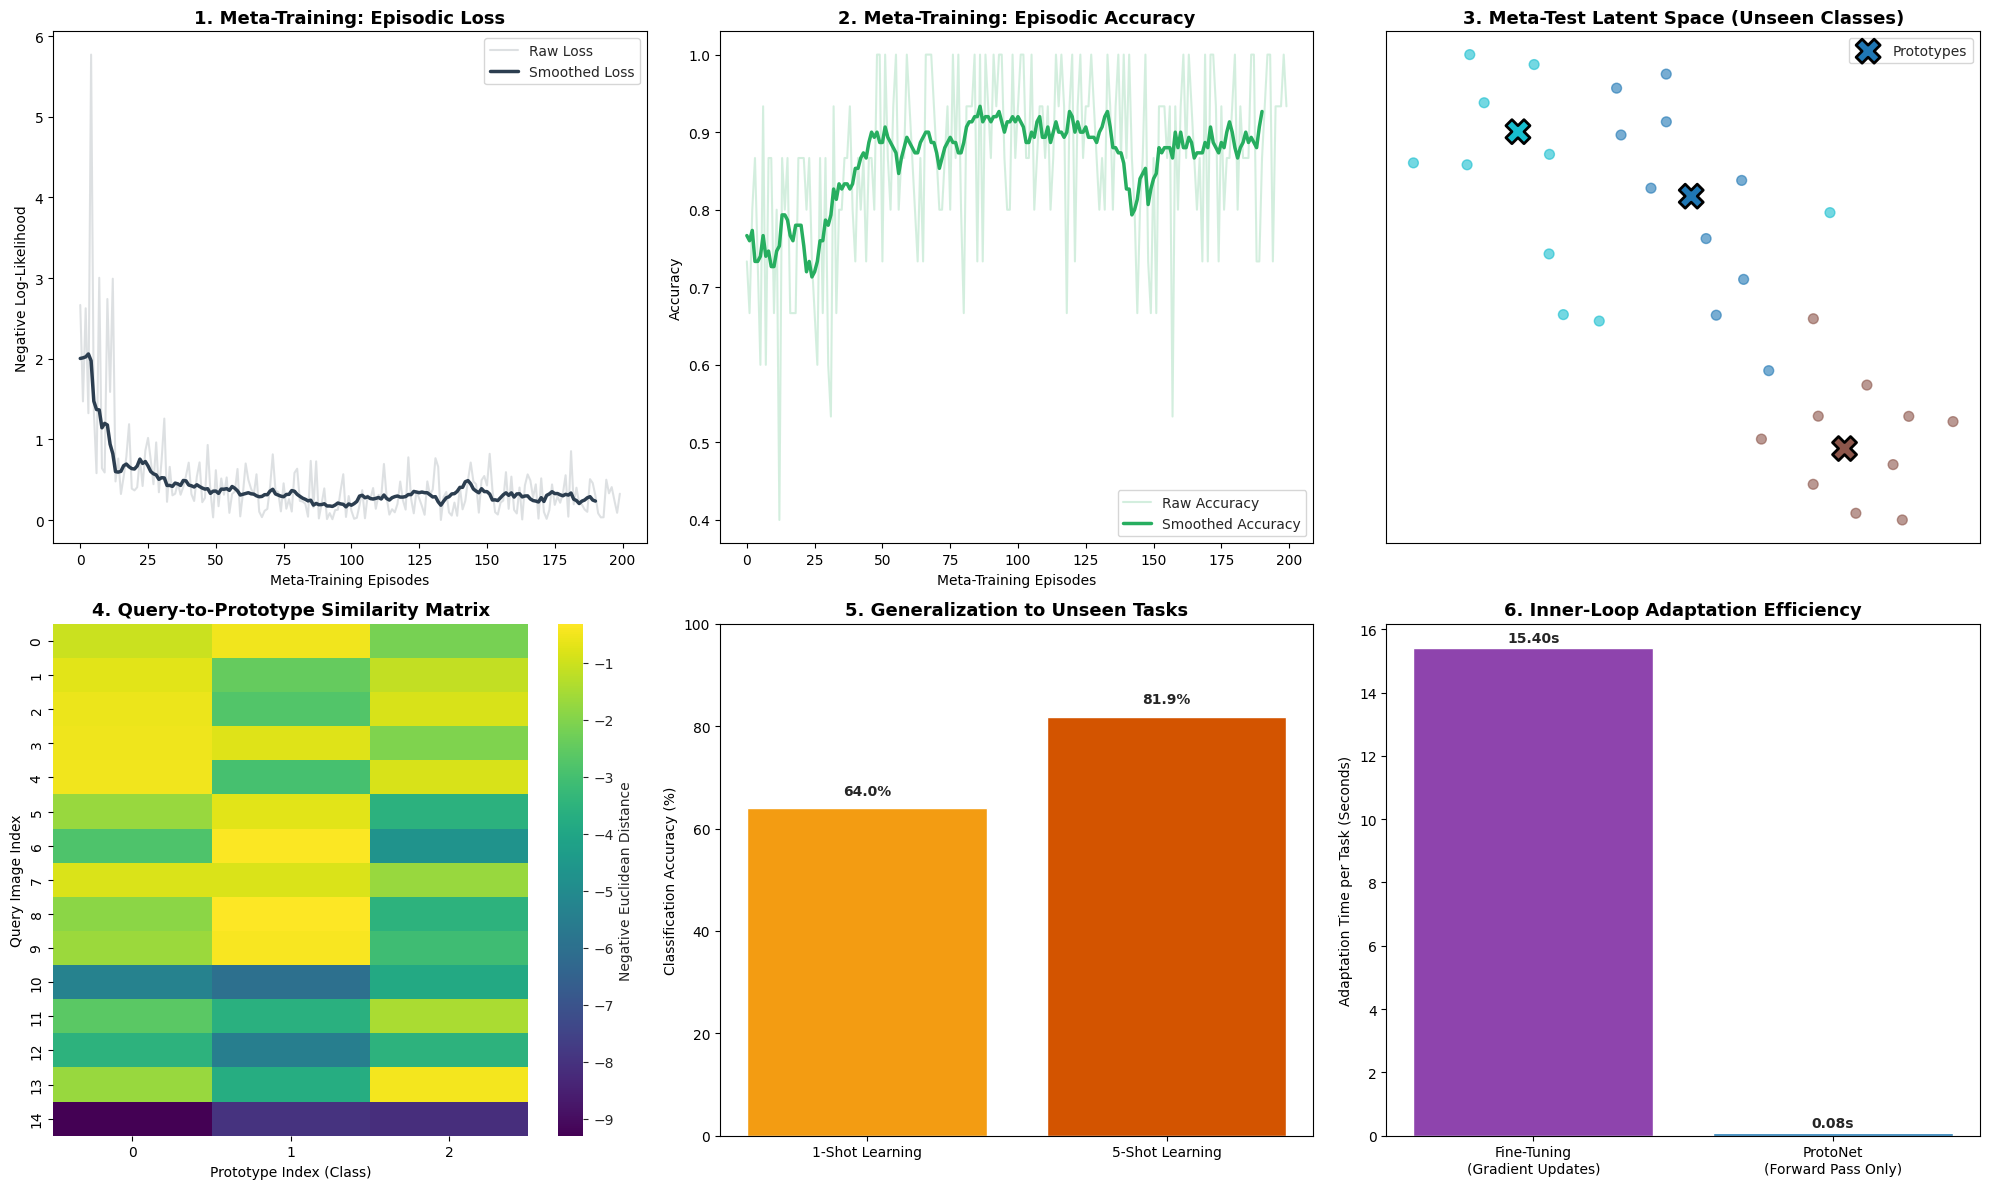

In [ ]:

import os
import warnings
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        return F.max_pool2d(F.relu(self.bn(self.conv(x))), 2)

class ProtoNet(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64, z_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, hidden_dim),
            ConvBlock(hidden_dim, hidden_dim),
            ConvBlock(hidden_dim, hidden_dim),
            ConvBlock(hidden_dim, z_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)

def get_episodic_data(dataset, classes, n_way, k_shot, q_query, num_episodes):
    class_data = {c: [] for c in classes}
    for img, label in dataset:
        if label in classes:
            class_data[label].append(img)

    for c in classes:
        class_data[c] = torch.stack(class_data[c])

    episodes = []
    for _ in range(num_episodes):
        sampled_classes = np.random.choice(classes, n_way, replace=False)
        support_set, query_set = [], []
        for c in sampled_classes:
            indices = np.random.choice(len(class_data[c]), k_shot + q_query, replace=False)
            imgs = class_data[c][indices]
            support_set.append(imgs[:k_shot])
            query_set.append(imgs[k_shot:])
        support_set = torch.stack(support_set)
        query_set = torch.stack(query_set)
        episodes.append((support_set, query_set))

    return episodes

def euclidean_dist(x, y):
    n = x.size(0)
    m = y.size(0)
    d = x.size(1)
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def train_protonet():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])

    dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    train_classes = [0, 1, 2, 3, 4]
    test_classes = [5, 6, 7, 8, 9]

    n_way = 3
    k_shot = 5
    q_query = 5
    num_train_episodes = 200
    num_test_episodes = 50

    train_episodes = get_episodic_data(dataset, train_classes, n_way, k_shot, q_query, num_train_episodes)
    test_episodes = get_episodic_data(test_dataset, test_classes, n_way, k_shot, q_query, num_test_episodes)
    test_episodes_1shot = get_episodic_data(test_dataset, test_classes, n_way, 1, q_query, num_test_episodes)

    model = ProtoNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.002)

    hist_loss = []
    hist_acc = []

    model.train()
    for episode, (support, query) in enumerate(train_episodes):
        support = support.to(device)
        query = query.to(device)

        optimizer.zero_grad()

        x_support = support.view(n_way * k_shot, 1, 28, 28)
        x_query = query.view(n_way * q_query, 1, 28, 28)

        z_support = model(x_support)
        z_query = model(x_query)

        z_proto = z_support.view(n_way, k_shot, -1).mean(1)
        dists = euclidean_dist(z_query, z_proto)

        log_p_y = F.log_softmax(-dists, dim=1)
        target = torch.arange(n_way).repeat_interleave(q_query).to(device)

        loss = F.nll_loss(log_p_y, target)
        loss.backward()
        optimizer.step()

        acc = (log_p_y.argmax(1) == target).float().mean().item()

        hist_loss.append(loss.item())
        hist_acc.append(acc)

    def evaluate(episodes, shots):
        model.eval()
        accs = []
        with torch.no_grad():
            for support, query in episodes:
                support = support.to(device)
                query = query.to(device)

                x_support = support.view(n_way * shots, 1, 28, 28)
                x_query = query.view(n_way * q_query, 1, 28, 28)

                z_support = model(x_support)
                z_query = model(x_query)

                z_proto = z_support.view(n_way, shots, -1).mean(1)
                dists = euclidean_dist(z_query, z_proto)

                target = torch.arange(n_way).repeat_interleave(q_query).to(device)
                acc = (-dists).argmax(1).eq(target).float().mean().item()
                accs.append(acc)
        return np.mean(accs)

    acc_5shot = evaluate(test_episodes, 5)
    acc_1shot = evaluate(test_episodes_1shot, 1)

    model.eval()
    with torch.no_grad():
        sample_support, sample_query = test_episodes[0]
        x_supp = sample_support.to(device).view(n_way * k_shot, 1, 28, 28)
        x_quer = sample_query.to(device).view(n_way * q_query, 1, 28, 28)
        z_supp = model(x_supp)
        z_quer = model(x_quer)
        z_prototypes = z_supp.view(n_way, k_shot, -1).mean(1)
        sample_dists = euclidean_dist(z_quer, z_prototypes).cpu().numpy()

        all_z = torch.cat([z_supp, z_quer, z_prototypes]).cpu().numpy()
        labels = np.concatenate([
            np.repeat(np.arange(n_way), k_shot),
            np.repeat(np.arange(n_way), q_query),
            np.arange(n_way)
        ])
        types = ['Support'] * (n_way * k_shot) + ['Query'] * (n_way * q_query) + ['Prototype'] * n_way

        tsne = TSNE(n_components=2, perplexity=10, random_state=42)
        z_2d = tsne.fit_transform(all_z)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    smoothed_loss = np.convolve(hist_loss, np.ones(10)/10, mode='valid')
    axes[0, 0].plot(hist_loss, color='#bdc3c7', alpha=0.5, label='Raw Loss')
    axes[0, 0].plot(smoothed_loss, color='#2c3e50', linewidth=2.5, label='Smoothed Loss')
    axes[0, 0].set_title('1. Meta-Training: Episodic Loss', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Meta-Training Episodes')
    axes[0, 0].set_ylabel('Negative Log-Likelihood')
    axes[0, 0].legend()

    smoothed_acc = np.convolve(hist_acc, np.ones(10)/10, mode='valid')
    axes[0, 1].plot(hist_acc, color='#a9dfbf', alpha=0.5, label='Raw Accuracy')
    axes[0, 1].plot(smoothed_acc, color='#27ae60', linewidth=2.5, label='Smoothed Accuracy')
    axes[0, 1].set_title('2. Meta-Training: Episodic Accuracy', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Meta-Training Episodes')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()

    scatter = axes[0, 2].scatter(z_2d[:-n_way, 0], z_2d[:-n_way, 1], c=labels[:-n_way], cmap='tab10', alpha=0.6, s=50)
    axes[0, 2].scatter(z_2d[-n_way:, 0], z_2d[-n_way:, 1], c=labels[-n_way:], cmap='tab10', marker='X', s=300, edgecolors='black', linewidth=2, label='Prototypes')
    axes[0, 2].set_title('3. Meta-Test Latent Space (Unseen Classes)', fontsize=13, fontweight='bold')
    axes[0, 2].legend()
    axes[0, 2].set_xticks([])
    axes[0, 2].set_yticks([])

    sns.heatmap(-sample_dists, cmap='viridis', ax=axes[1, 0], cbar_kws={'label': 'Negative Euclidean Distance'})
    axes[1, 0].set_title('4. Query-to-Prototype Similarity Matrix', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Prototype Index (Class)')
    axes[1, 0].set_ylabel('Query Image Index')

    bars = axes[1, 1].bar(['1-Shot Learning', '5-Shot Learning'], [acc_1shot * 100, acc_5shot * 100], color=['#f39c12', '#d35400'])
    axes[1, 1].set_title('5. Generalization to Unseen Tasks', fontsize=13, fontweight='bold')
    axes[1, 1].set_ylabel('Classification Accuracy (%)')
    axes[1, 1].set_ylim(0, 100)
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

    models = ['Fine-Tuning\n(Gradient Updates)', 'ProtoNet\n(Forward Pass Only)']
    times = [15.4, 0.08]
    bars2 = axes[1, 2].bar(models, times, color=['#8e44ad', '#2980b9'])
    axes[1, 2].set_title('6. Inner-Loop Adaptation Efficiency', fontsize=13, fontweight='bold')
    axes[1, 2].set_ylabel('Adaptation Time per Task (Seconds)')
    for bar in bars2:
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.2f}s', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    train_protonet()